# Clasificación de Residuos — Modelo A5/D5: CNN Frontier

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de complejidad creciente** para estudiar el impacto de la arquitectura en el rendimiento de redes neuronales convolucionales aplicadas a la clasificación de residuos.

### Estrategia Experimental

- **Punto de partida**: Modelo baseline A1 (red simple del notebook 2.3)
- **Enfoque**: Incrementos progresivos en la capacidad del modelo
- **Observables**: Evolución del error de entrenamiento y validación

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo A5/D5

### Descripción

**CNN Frontier** es el **punto de encuentro** entre la serie ascendente (A) y descendente (D). Representa la **máxima complejidad razonable** para entrenar desde cero con el dataset TrashNet (~2.5K imágenes).

Este modelo incorpora:
- **4 bloques convolucionales** con progresión de filtros (32→64→128→256)
- **BatchNormalization** en todas las capas para estabilización
- **Capa Dense intermedia (128)** + Dropout para mayor capacidad de generalización
- **~500K parámetros** (cerca del límite razonable: nº_parámetros << datos × 10)

### Modificaciones Respecto a A4

| Componente | A4 (Anterior) | A5/D5 (Este modelo) |
|------------|---------------|---------------------|
| **Capas Conv** | 3 capas (32, 64, 128) | **4 capas** (32, 64, 128, 256) |
| **Dense intermedia** | No | **Sí** (128 neuronas) |
| **Dropout** | No | **Sí** (0.4) |
| **MaxPooling** | **3×** (tras conv1, conv2, conv3) | **3×** (tras conv1, conv2, conv3) |
| **Parámetros** | **~95K** | **~424** |


**Nota**: Este es simultáneamente el modelo **A5** (más complejo de la serie ascendente) y **D5** (punto de partida de la serie descendente de complejidad).

---

## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| **A5/D5 (CNN Frontier)** | **424,006** | **0.8395** | **0.8354** | **0.8081** | **0.8140** |

---

## Implementación

A continuación se entrena y evalúa el modelo A5/D5 usando el pipeline estándar del proyecto.

In [1]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score  
)


# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

2026-03-13 13:51:13.226955: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 13:51:13.227160: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 13:51:13.254010: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 13:51:13.881340: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

---
## 1. Carga de datos

In [2]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


---
## 2. Definición del modelo

In [3]:
# ========================================
# 2.1 DATASET + AUMENTACION
# ========================================

SEED = 44
BATCH_SIZE = 64
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val,   training=False)

print('Datasets con augmentacion listos')

E0000 00:00:1773406278.838052 2233053 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773406278.845819 2233053 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Datasets con augmentacion listos


In [4]:
# ========================================
# 3. DEFINICION DEL MODELO A5/D5
# ========================================

from models.A5_D5_cnn_frontier import build_cnn_frontier as build_model

model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "A5_D5_CNN_Frontier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

---
## 3. Entrenamiento

In [ ]:
# ========================================
# 4. CONFIGURACION Y ENTRENAMIENTO
# ========================================

MODEL_NAME = 'A5_D5_cnn_frontier'

# ── Callbacks ────────────────────────────────────────────────────
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0
)

# ── Scheduler CosineDecay ────────────────────────────────────────
EPOCHS = 100
steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS

lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-2
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=lr_scheduler,
        weight_decay=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Entrenamiento ────────────────────────────────────────────────────────────
history_p1 = model.fit(
    ds_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[cb_early_stop, cb_checkpoint],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 831ms/step - accuracy: 0.4859 - loss: 1.3601 - val_accuracy: 0.1979 - val_loss: 1.7915
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 822ms/step - accuracy: 0.5809 - loss: 1.1169 - val_accuracy: 0.1979 - val_loss: 1.9325
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 831ms/step - accuracy: 0.6154 - loss: 1.0389 - val_accuracy: 0.1979 - val_loss: 2.0870
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 836ms/step - accuracy: 0.6312 - loss: 0.9957 - val_accuracy: 0.1900 - val_loss: 2.1511
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 826ms/step - accuracy: 0.6686 - loss: 0.9333 - val_accuracy: 0.3034 - val_loss: 2.2033
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 825ms/step - accuracy: 0.6793 - loss: 0.8713 - val_accuracy: 0.2164 - val_loss: 2.2133
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 834ms/step - accuracy: 0.6861 - loss: 0.8679 - val_accuracy: 0.1979 - val_loss: 2.4708
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 834ms/step - accuracy: 0.7121 - loss: 0.8198 - 

---
## 4. Curvas de entrenamiento

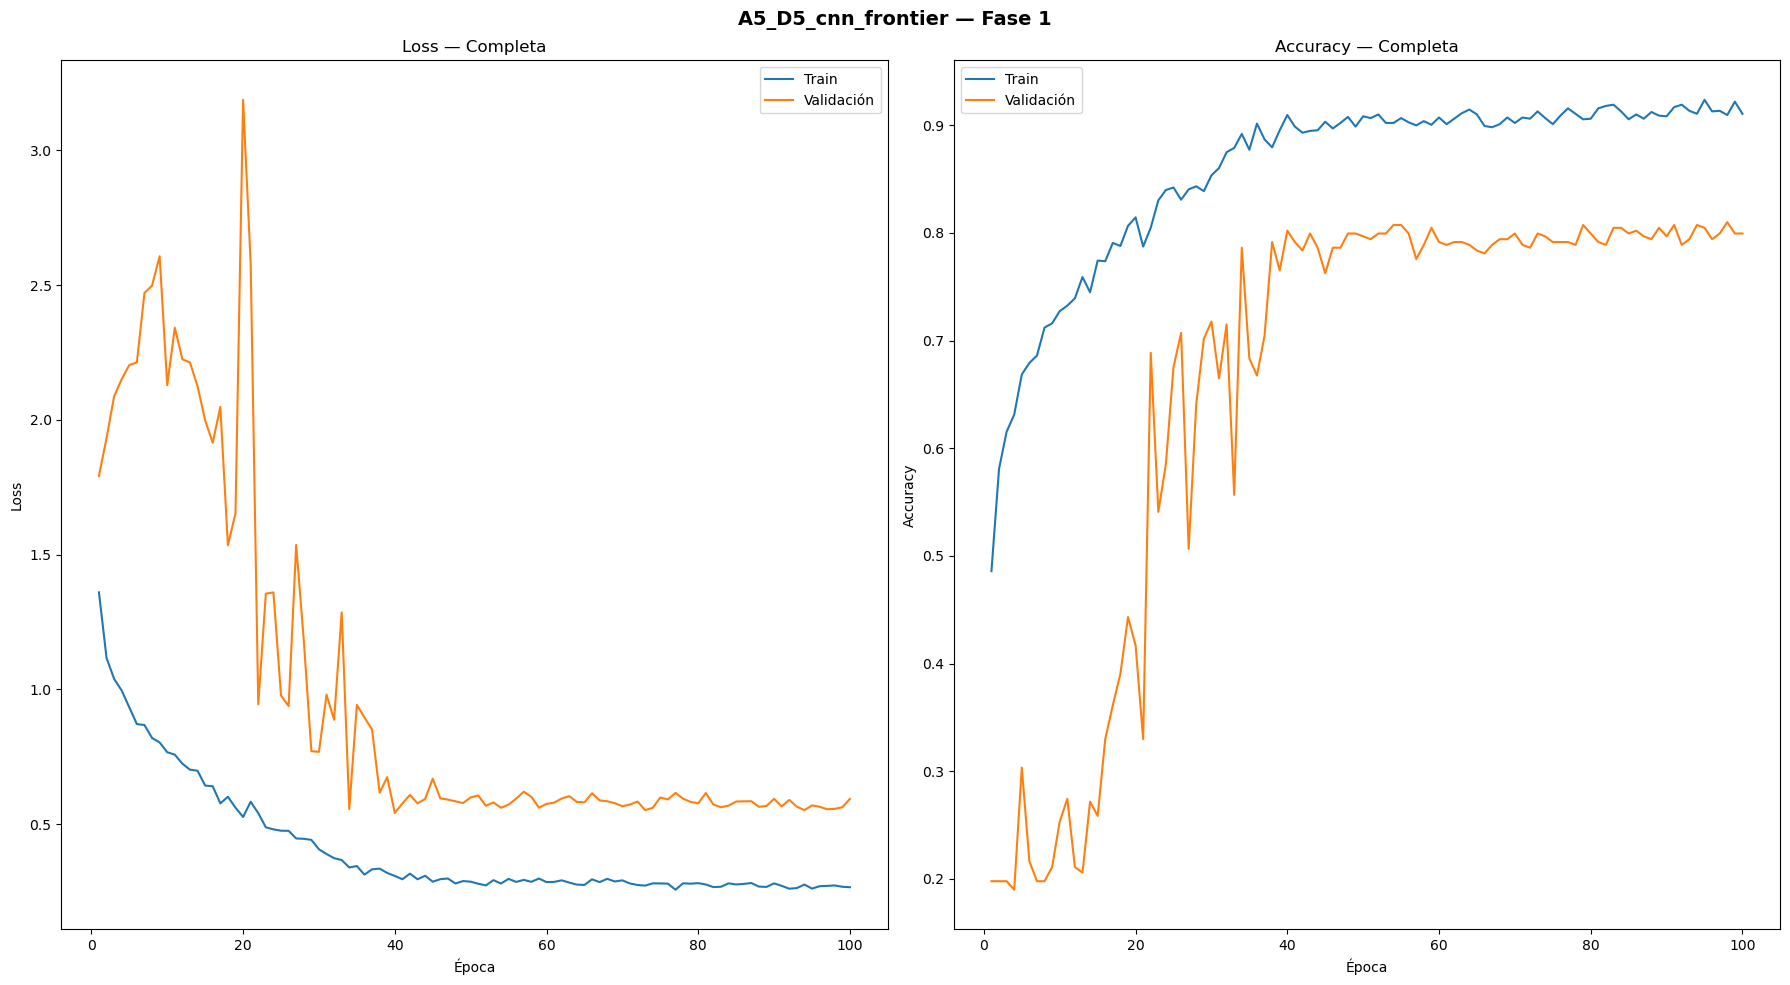

In [12]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)

---
## 5. Evaluación — Train / Val / Test

In [13]:
def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


print('=' * 60)
print(f'Modelo: {MODEL_NAME}')
print('=' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('=' * 60)

Modelo: A5_D5_cnn_frontier
[Train]  Acc=0.9021  Prec=0.8971  Rec=0.8966  F1=0.8949
[  Val]  Acc=0.8100  Prec=0.7944  Rec=0.7964  F1=0.7917
[ Test]  Acc=0.8395  Prec=0.8354  Rec=0.8081  F1=0.8140


In [14]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 424,006
Parámetros entrenables: 423,046


---
## 6. Métricas por partición

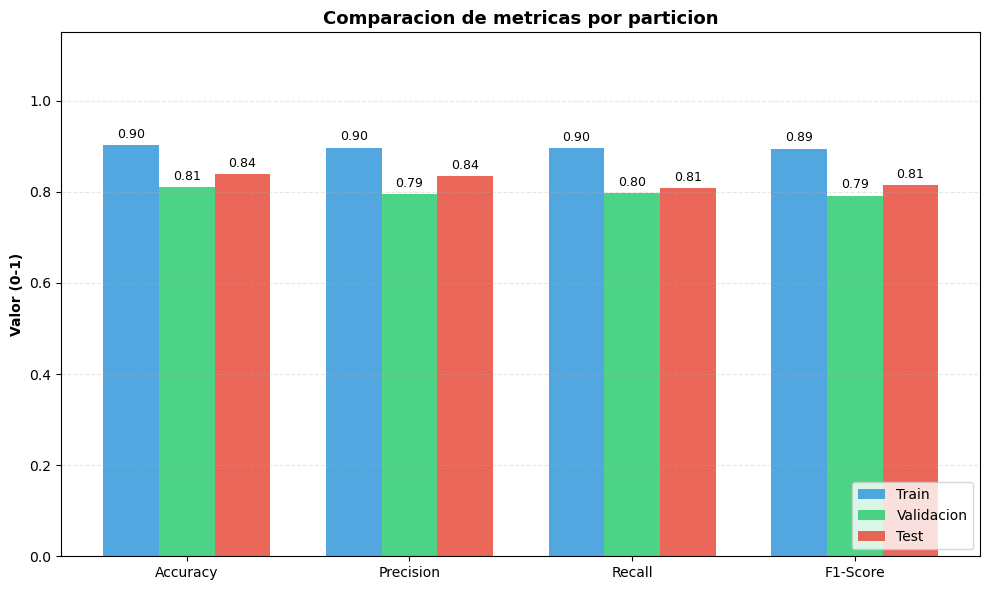

In [15]:
# ========================================
# GRAFICO DE BARRAS DE METRICAS (TRAIN / VAL / TEST)
# ========================================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

results_train = [res_train['acc'], res_train['prec'], res_train['rec'], res_train['f1']]
results_val   = [res_val['acc'],   res_val['prec'],   res_val['rec'],   res_val['f1']]
results_test  = [res_test['acc'],  res_test['prec'],  res_test['rec'],  res_test['f1']]

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, results_train, width, label='Train', color='#3498db', alpha=0.85)
rects2 = ax.bar(x,         results_val,   width, label='Validacion', color='#2ecc71', alpha=0.85)
rects3 = ax.bar(x + width, results_test,  width, label='Test', color='#e74c3c', alpha=0.85)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9
        )

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparacion de metricas por particion', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 7. Matrices de confusión

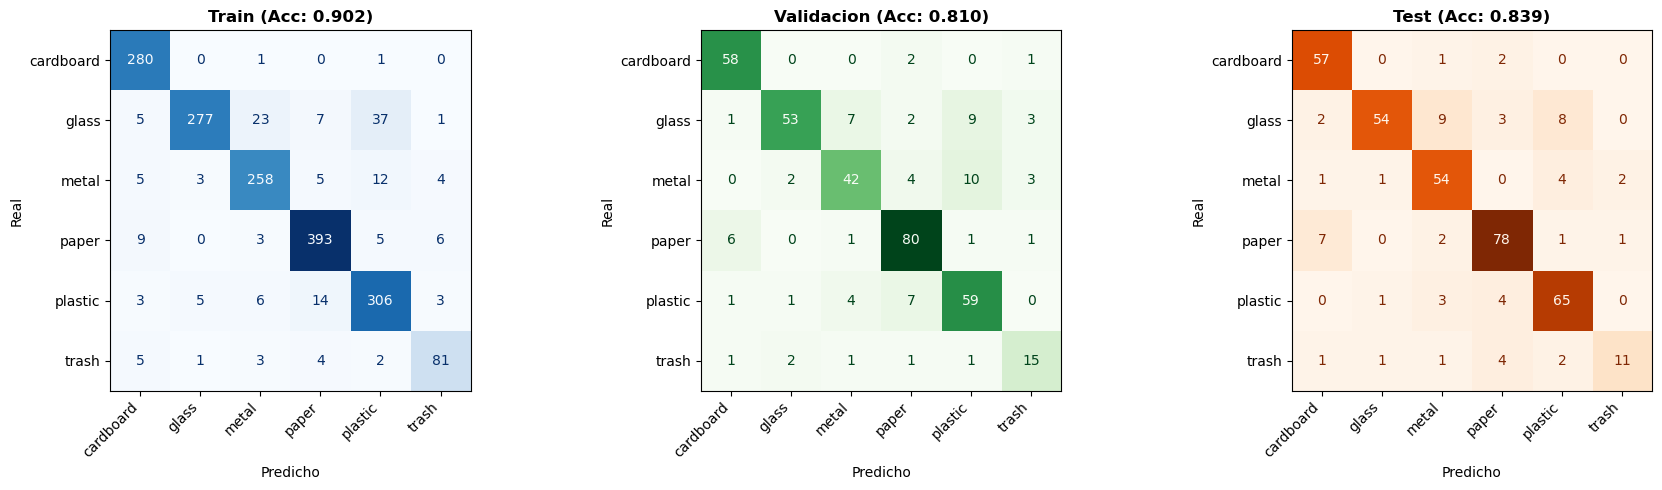

              precision    recall  f1-score   support

   cardboard       0.84      0.95      0.89        60
       glass       0.95      0.71      0.81        76
       metal       0.77      0.87      0.82        62
       paper       0.86      0.88      0.87        89
     plastic       0.81      0.89      0.85        73
       trash       0.79      0.55      0.65        20

    accuracy                           0.84       380
   macro avg       0.84      0.81      0.81       380
weighted avg       0.85      0.84      0.84       380



In [16]:
# ========================================
# MATRICES DE CONFUSION PARA TRAIN / VAL / TEST
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_pred_train = res_train['y_pred']
y_pred_val   = res_val['y_pred']
y_pred_test  = res_test['y_pred']

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Train (Acc: {res_train['acc']:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicho', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validacion
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Validacion (Acc: {res_val['acc']:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicho', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title(f"Test (Acc: {res_test['acc']:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicho', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'confusion_{MODEL_NAME}_all_splits.png', dpi=150)
plt.show()

print(classification_report(
    y_test,
    y_pred_test,
    target_names=class_names
))

---

## 8. Conclusiones — Modelo A5/D5 (CNN Frontier)

El modelo **A5_D5_cnn_frontier** marca el techo de la serie entrenada desde cero, incorporando un cuarto bloque convolucional, una capa densa intermedia y `Dropout`, lo que incrementa de forma clara la capacidad de representación sin perder estabilidad durante el entrenamiento.

La diferencia entre entrenamiento y validación sigue siendo moderada, pero ya se aprecia una **brecha más visible que en A4**, algo esperable al acercarse al límite de complejidad razonable para TrashNet. Aun así, el modelo logra la **mejor precisión en test de toda la serie A**, confirmando que el aumento de capacidad todavía aporta valor antes de pasar a estrategias de **Transfer Learning**.

### Comparación de modelos: A1 vs A2 vs A3 vs A4 vs A5/D5

| Modelo | Partición | Accuracy | Precision | Recall | F1-Score |
|--------|-----------|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | Train | 0.4717 | 0.4138 | 0.4100 | 0.3937 |
| A1 (SimpleCNN) | Val | 0.4802 | 0.4406 | 0.4138 | 0.4030 |
| A1 (SimpleCNN) | Test | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | Train | 0.6400 | 0.6300 | 0.5700 | 0.5700 |
| A2 (CNN Small) | Val | 0.6200 | 0.6500 | 0.5500 | 0.5600 |
| A2 (CNN Small) | Test | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | Train | 0.8360 | 0.8268 | 0.8121 | 0.8184 |
| A3 (CNN Medium) | Val | 0.7414 | 0.7149 | 0.6954 | 0.7010 |
| A3 (CNN Medium) | Test | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | Train | 0.8343 | 0.8146 | 0.8346 | 0.8127 |
| A4 (CNN Large) | Val | 0.7546 | 0.7480 | 0.7558 | 0.7301 |
| A4 (CNN Large) | Test | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| **A5/D5 (CNN Frontier)** | **Train** | **0.9021** | **0.8971** | **0.8966** | **0.8949** |
| **A5/D5 (CNN Frontier)** | **Val** | **0.8100** | **0.7944** | **0.7964** | **0.7917** |
| **A5/D5 (CNN Frontier)** | **Test** | **0.8395** | **0.8354** | **0.8081** | **0.8140** |

### Comparación de rendimiento en el conjunto de Test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| **A5/D5 (CNN Frontier)** | **424,006** | **0.8395** | **0.8354** | **0.8081** | **0.8140** |